In [1]:
import warnings
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, sgt_scaling_plot, MaximumLikelihoodEstimation

warnings.filterwarnings("ignore", category=RuntimeWarning)
# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# 1. Simulate synthetic data
# -----------------------------
np.random.seed(42)

N = np.random.randint(50, 2000, size=400)          # node counts
alpha0, alpha1 = -2.0, 0.8                         # mean params
beta0,  beta1  = 0.5,  0.1                         # std params

mu = alpha0 + alpha1 * np.log(N)
sigma = np.clip(beta0 + beta1 * np.log(N), 1e-3, None)
X = np.exp(np.random.normal(mu, sigma))             # lognormal samples

df = pd.DataFrame({"N": N, "X": X})
df["logN"] = np.log(df["N"])
df["logX"] = np.log(df["X"])


# -----------------------------
# 2. Fit via MLE
# -----------------------------
res = MaximumLikelihoodEstimation.lognormal(df["N"].values, df["X"].values)
a0, a1, b0, b1 = res["alpha0"], res["alpha1"], res["beta0"], res["beta1"]

Fitted parameters:
alpha0=-2.438, alpha1=0.866, beta0=0.315, beta1=0.125


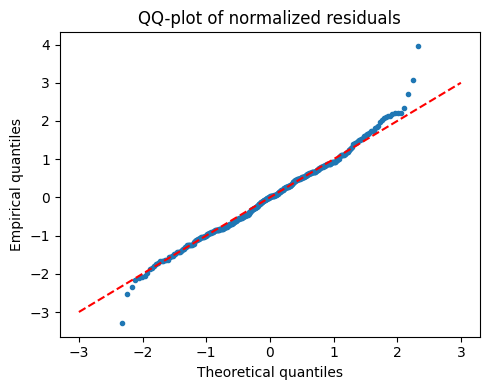

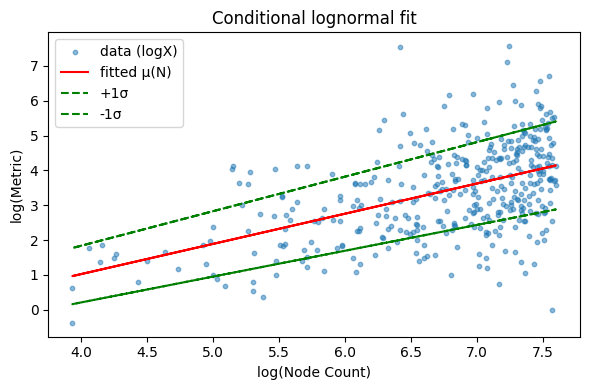

In [17]:
# -----------------------------
# 3. Diagnostics
# -----------------------------
mu_hat = a0 + a1 * df["logN"]
sigma_hat = np.clip(b0 + b1 * df["logN"], 1e-6, None)
resid = (df["logX"] - mu_hat) / sigma_hat

# QQ plot
plt.figure(figsize=(5,4))
norm_prob = np.sort(norm.ppf(np.linspace(0.01,0.99,len(resid))))
plt.plot(norm_prob, np.sort(resid), '.')
plt.plot([-3,3], [-3,3], 'r--')
plt.xlabel("Theoretical quantiles")
plt.ylabel("Empirical quantiles")
plt.title("QQ-plot of normalized residuals")
plt.tight_layout()
plt.show()

# Conditional mean and variance vs N
df["mu_hat"] = mu_hat
df["sigma_hat"] = sigma_hat

plt.figure(figsize=(6,4))
plt.scatter(df["logN"], df["logX"], s=10, alpha=0.5, label="data (logX)")
plt.plot(df["logN"], mu_hat, 'r', label="fitted μ(N)")
plt.plot(df["logN"], mu_hat + sigma_hat, 'g--', label="+1σ")
plt.plot(df["logN"], mu_hat - sigma_hat, 'g--', label="-1σ")
plt.xlabel("log(Node Count)")
plt.ylabel("log(Metric)")
plt.legend()
plt.title("Conditional lognormal fit")
plt.tight_layout()
plt.show()

In [2]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "n_200/"
pdf_file = "n_200/scaling_results-gamma.pdf"
plt_figs = []

all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)
print(all_sheets.keys())

dict_keys(['Nodes-Edges', 'Nodes-Edges(Fit)', 'Nodes-Degree', 'Nodes-Degree(Fit)', 'Nodes-Diameter', 'Nodes-Diameter(Fit)', 'Nodes-Density', 'Nodes-Density(Fit)', 'Nodes-ASC', 'Nodes-ASC(Fit)', 'Nodes-ACC', 'Nodes-ACC(Fit)', 'Nodes-BC', 'Nodes-BC(Fit)', 'Nodes-EC', 'Nodes-EC(Fit)', 'Nodes-CC', 'Nodes-CC(Fit)', 'Nodes-GE', 'Nodes-GE(Fit)'])


In [3]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

In [ ]:
"""
Kernel Size vs Nodes
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Kernel Size", df_edges, material_labels, skip_test=True)
plt_figs.append(plt_fig)

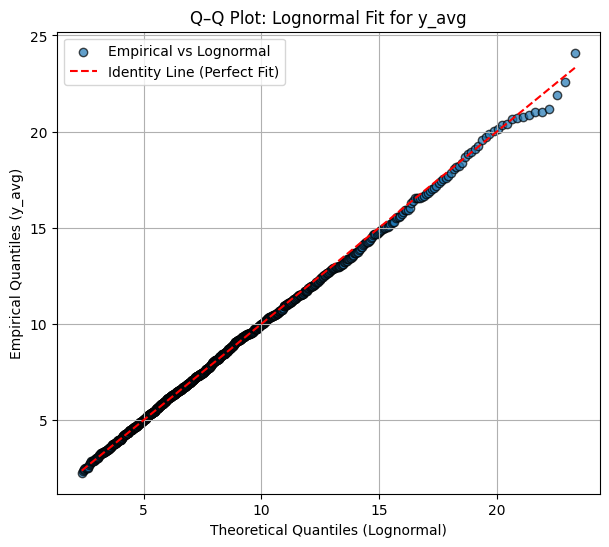

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df_dens = all_sheets['Nodes-Density']
df_sample = df_dens[df_dens['Material'] == 'BSE 017']
y_avg = df_sample['y-avg'].to_numpy()
# mod_fit = sm.OLS(y_avg, sm.add_constant(y_avg)).fit()
# res = mod_fit.resid
# sm.qqplot(res)
# py.show()

mu_normal = 2.0  # Mean of the underlying normal distribution
sigma_normal = 0.5  # Standard deviation of the underlying normal distribution
# Generate 1000 log-normal samples
y_avg = np.random.lognormal(mean=mu_normal, sigma=sigma_normal, size=1000)
#y_avg = df["X"].to_numpy()

# Step 2: Fit log-normal distribution to y_avg
# Fit returns (shape, loc, scale)
shape_fit, loc_fit, scale_fit = stats.lognorm.fit(y_avg, floc=0) # floc=0 fixes location at 0 (common for lognorm)

# Create Q-Q plot
# stats.probplot(y_avg, dist=stats.lognorm, sparams=(shape_fit, loc_fit, scale_fit), plot=plt)
# plt.title('Normal Q-Q plot')
# plt.xlabel('Theoretical quantiles')
# plt.ylabel('Ordered Values')
# plt.grid(True)
# plt.show()



# Step 3: Generate theoretical quantiles
# For QQ-plot, we compare sorted empirical y vs theoretical quantiles
quantiles = np.linspace(0.01, 0.99, len(y_avg))
theoretical_q = stats.lognorm.ppf(quantiles, shape_fit, loc=loc_fit, scale=scale_fit)
empirical_q = np.quantile(y_avg, quantiles)

# Step 4: Plot QQ-plot
plt.figure(figsize=(7, 6))
plt.scatter(theoretical_q, empirical_q, alpha=0.7, edgecolor="k", label="Empirical vs Lognormal")
plt.plot(theoretical_q, theoretical_q, 'r--', label="Identity Line (Perfect Fit)")
plt.xlabel("Theoretical Quantiles (Lognormal)")
plt.ylabel("Empirical Quantiles (y_avg)")
plt.title("Q–Q Plot: Lognormal Fit for y_avg")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sample_data = y_avg
# 2. Fit the lognormal distribution to the sample data
# floc=0 is used to fix the location parameter to 0, which is standard for many lognormal uses.
s_fit, loc_fit, scale_fit = stats.lognorm.fit(sample_data, floc=0)

print(f"Fitted parameters:")
print(f"  Shape (s): {s_fit:.4f}")
print(f"  Location (loc): {loc_fit:.4f}")
print(f"  Scale: {scale_fit:.4f}")

# 3. Calculate the residuals
# To do this, we compare the empirical CDF of the sample to the theoretical CDF
# of the fitted lognormal distribution.

# Sort the sample data to correctly compute the empirical CDF.
sample_data_sorted = np.sort(sample_data)

# Calculate the empirical CDF (eCDF)
# eCDF_vals[i] = (i + 1) / n
n = len(sample_data_sorted)
ecdf_vals = np.arange(1, n + 1) / n

# Calculate the theoretical CDF (tCDF) using the fitted parameters
tcdf_vals = stats.lognorm.cdf(sample_data_sorted, s=s_fit, loc=loc_fit, scale=scale_fit)

# Compute the residuals
residuals = ecdf_vals - tcdf_vals

# 4. Visualize the residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the ECDF vs TCDF
ax1.plot(sample_data_sorted, ecdf_vals, label="Empirical CDF (Sample)")
ax1.plot(sample_data_sorted, tcdf_vals, 'r--', label="Theoretical CDF (Fitted)")
ax1.set_title("CDF Comparison")
ax1.set_xlabel("Data Value")
ax1.set_ylabel("Cumulative Probability")
ax1.legend()
ax1.grid(True)

# Plot the residuals
ax2.plot(sample_data_sorted, residuals, 'o-', markersize=4)
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_title("Residuals (Empirical CDF - Theoretical CDF)")
ax2.set_xlabel("Data Value")
ax2.set_ylabel("Residual")
ax2.grid(True)

plt.tight_layout()
plt.show()

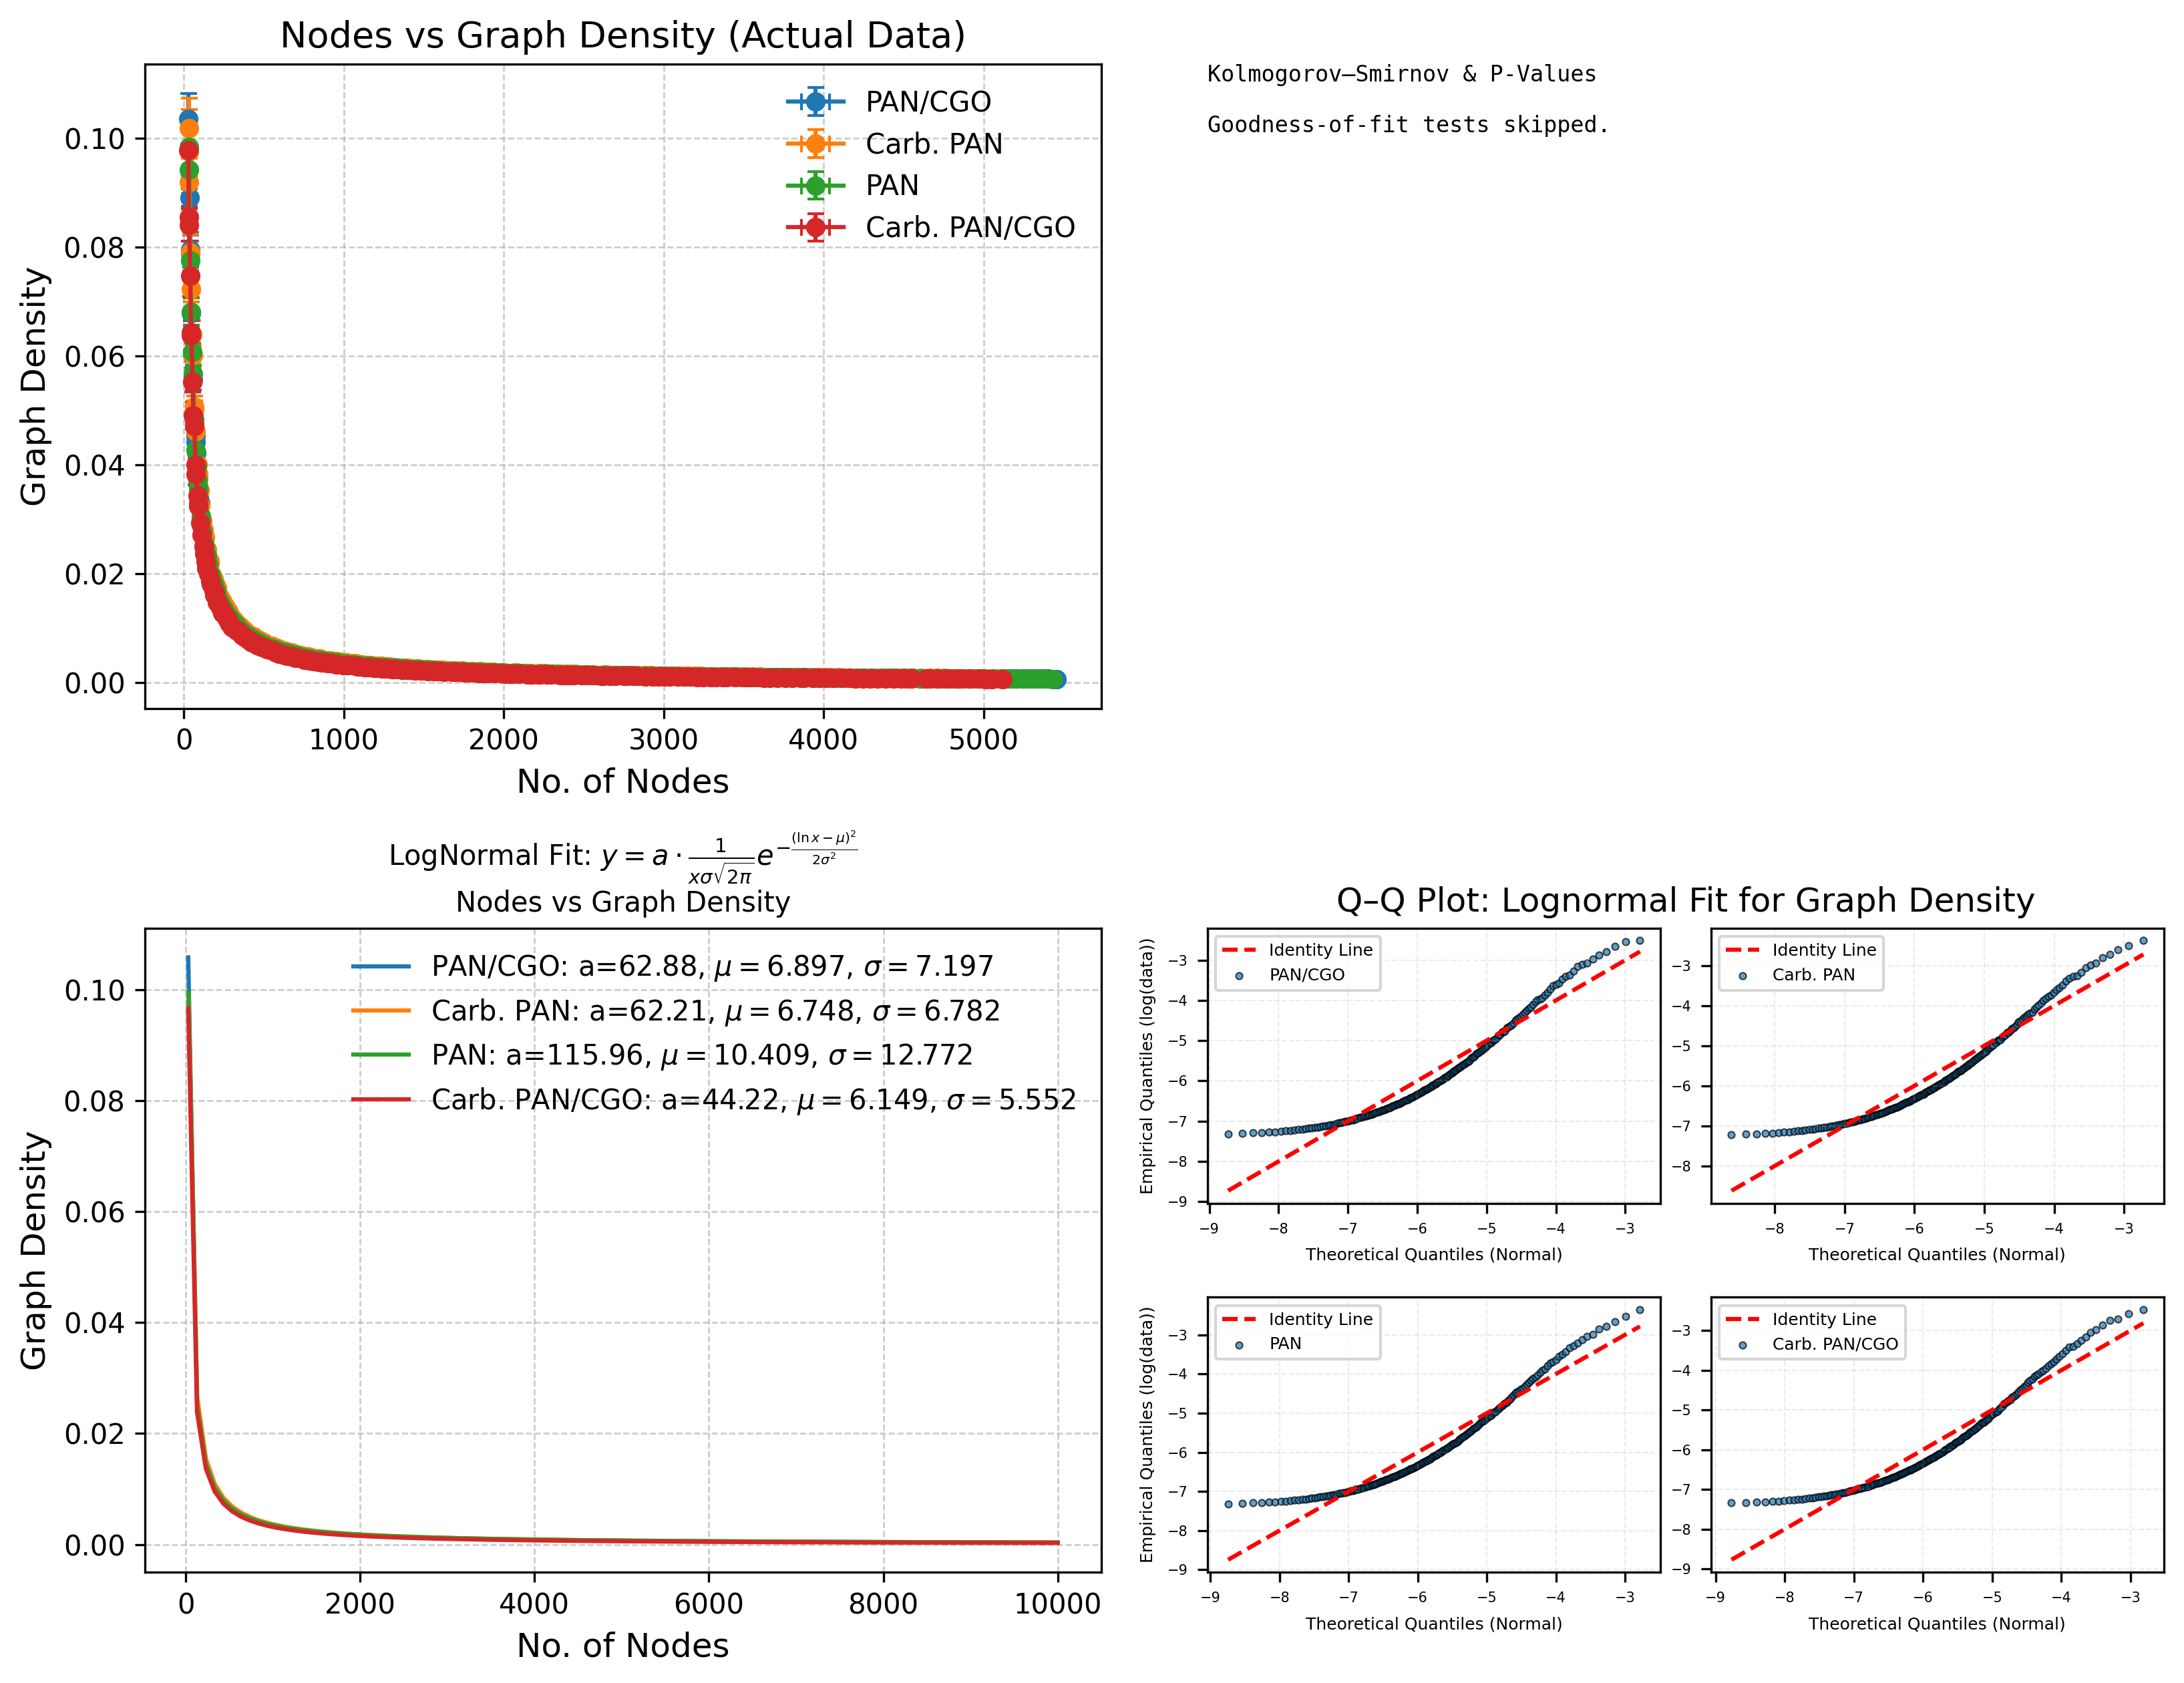

In [4]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']
plt_fig = sgt_scaling_plot("Graph Density", df_dens, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

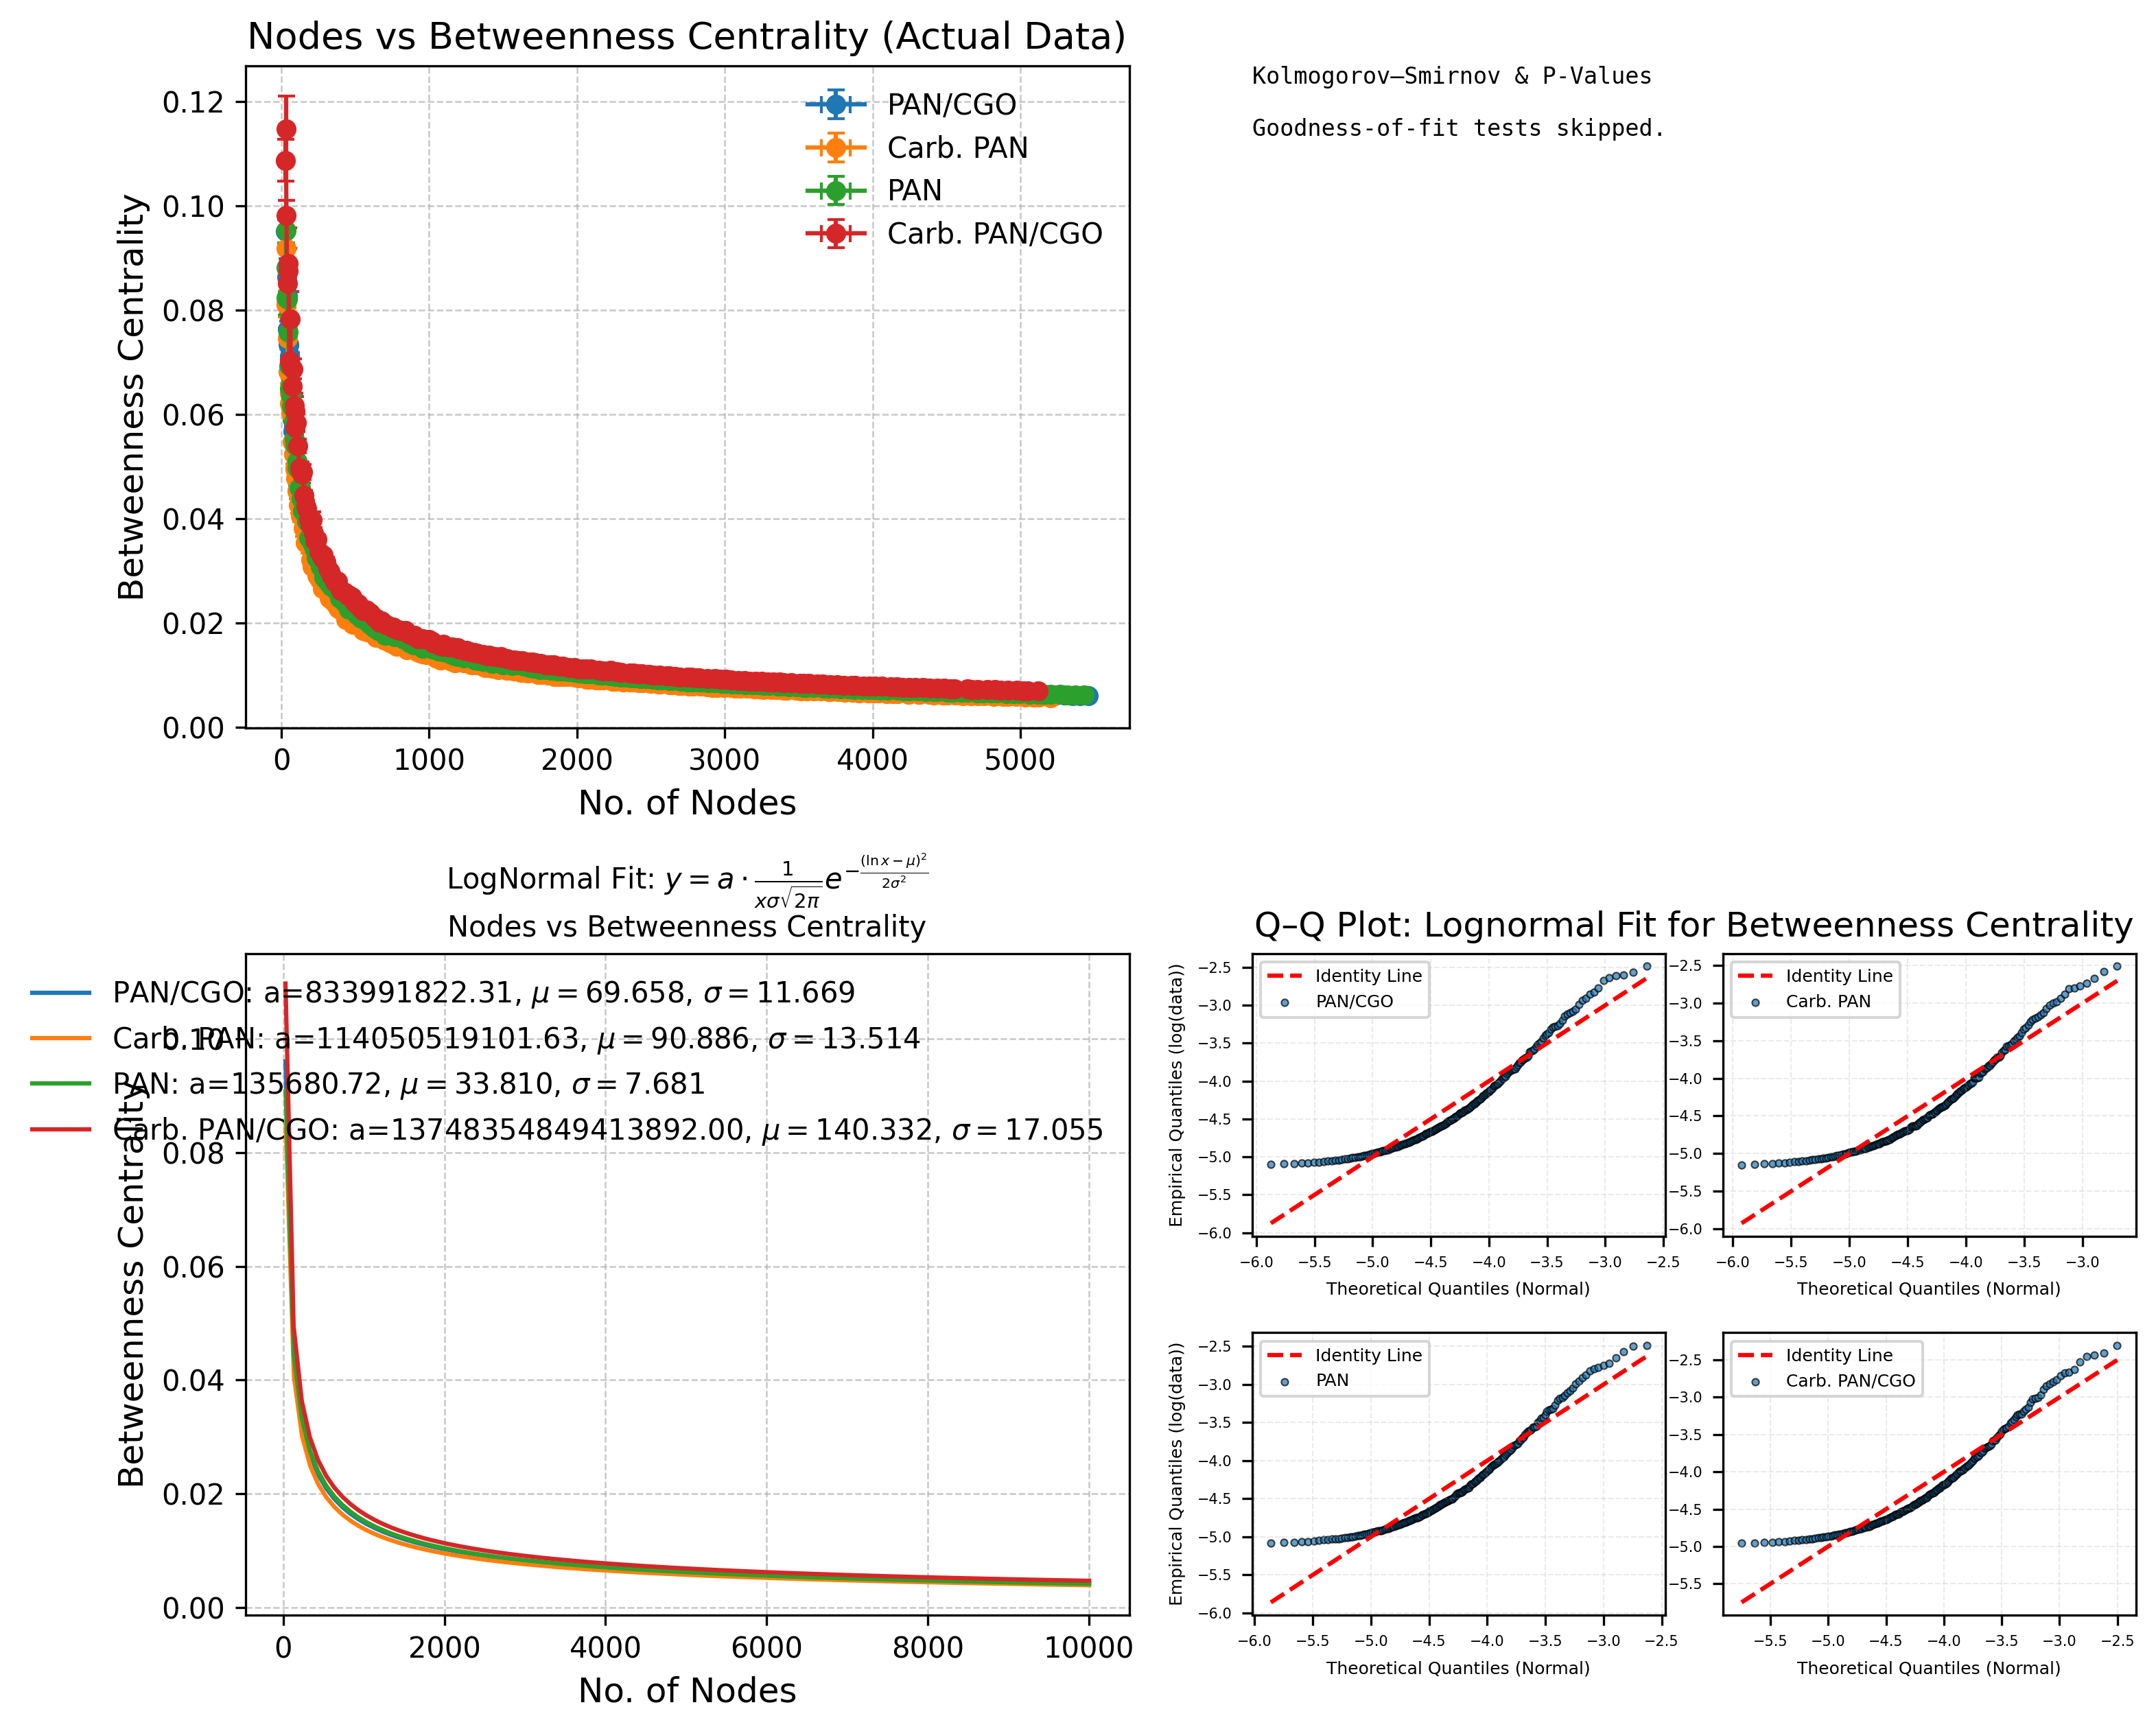

In [5]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']
plt_fig = sgt_scaling_plot("Betweenness Centrality", df_bet, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

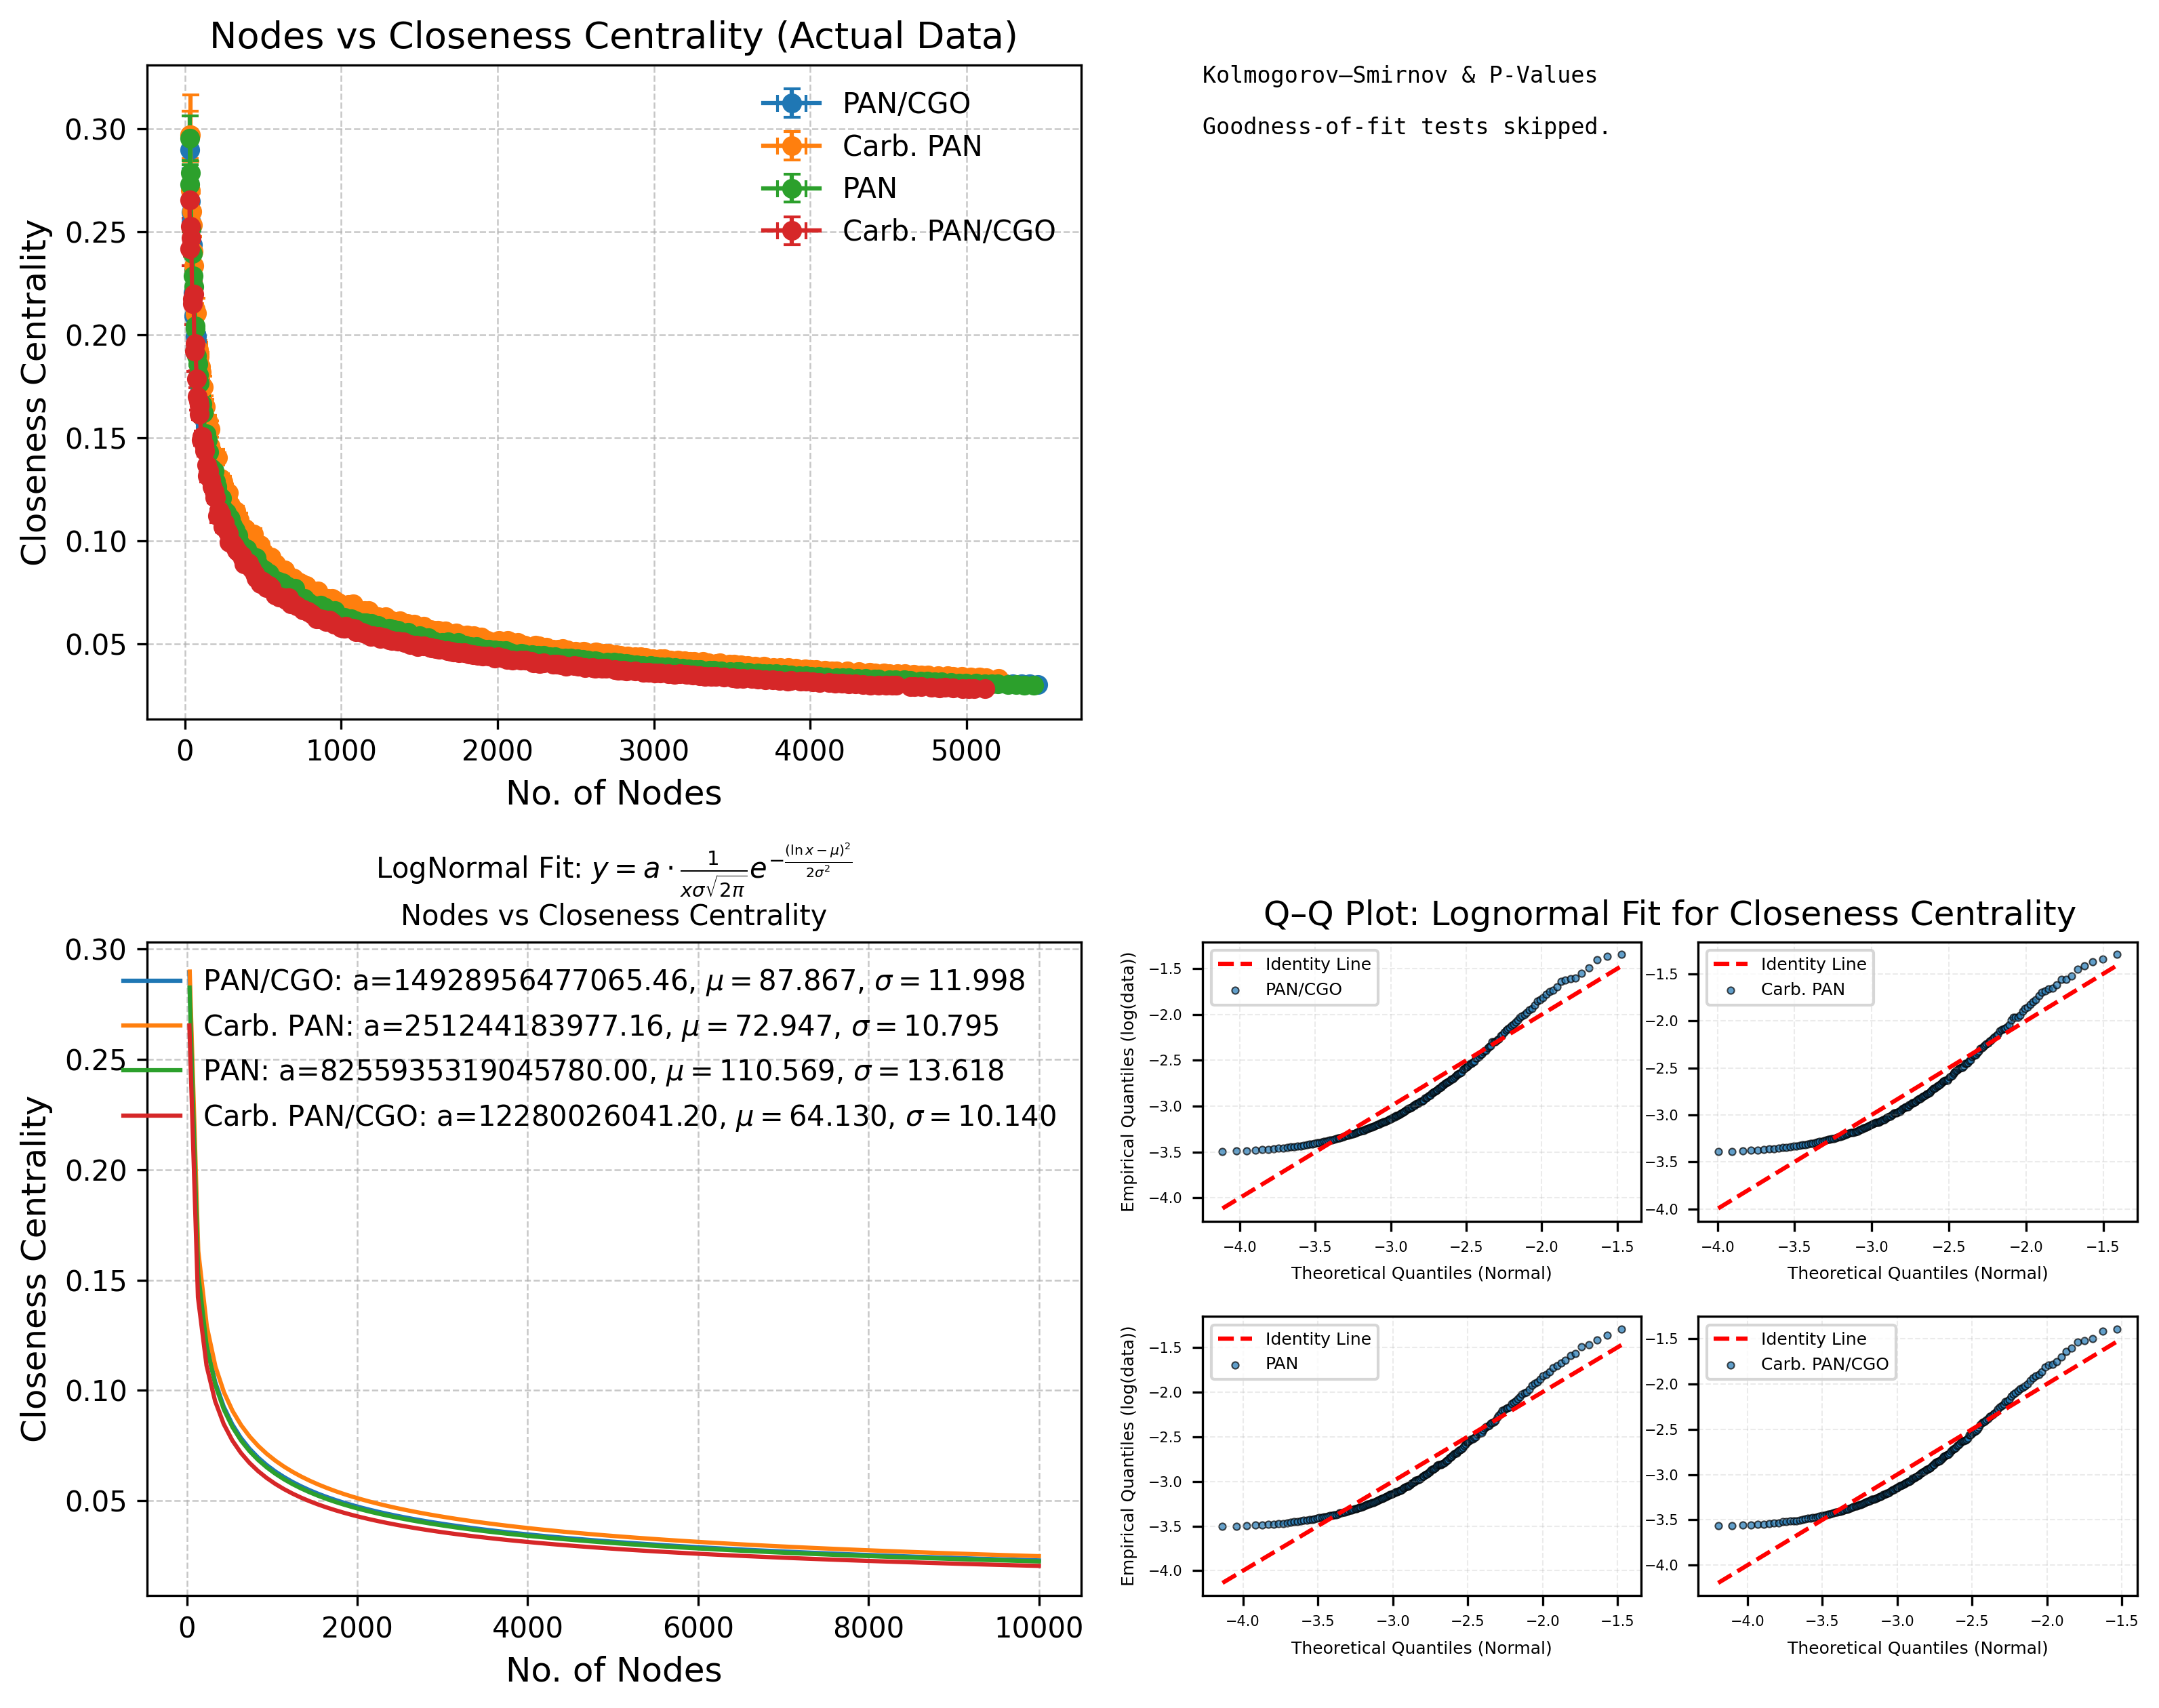

In [6]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']
plt_fig = sgt_scaling_plot("Closeness Centrality", df_clo, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

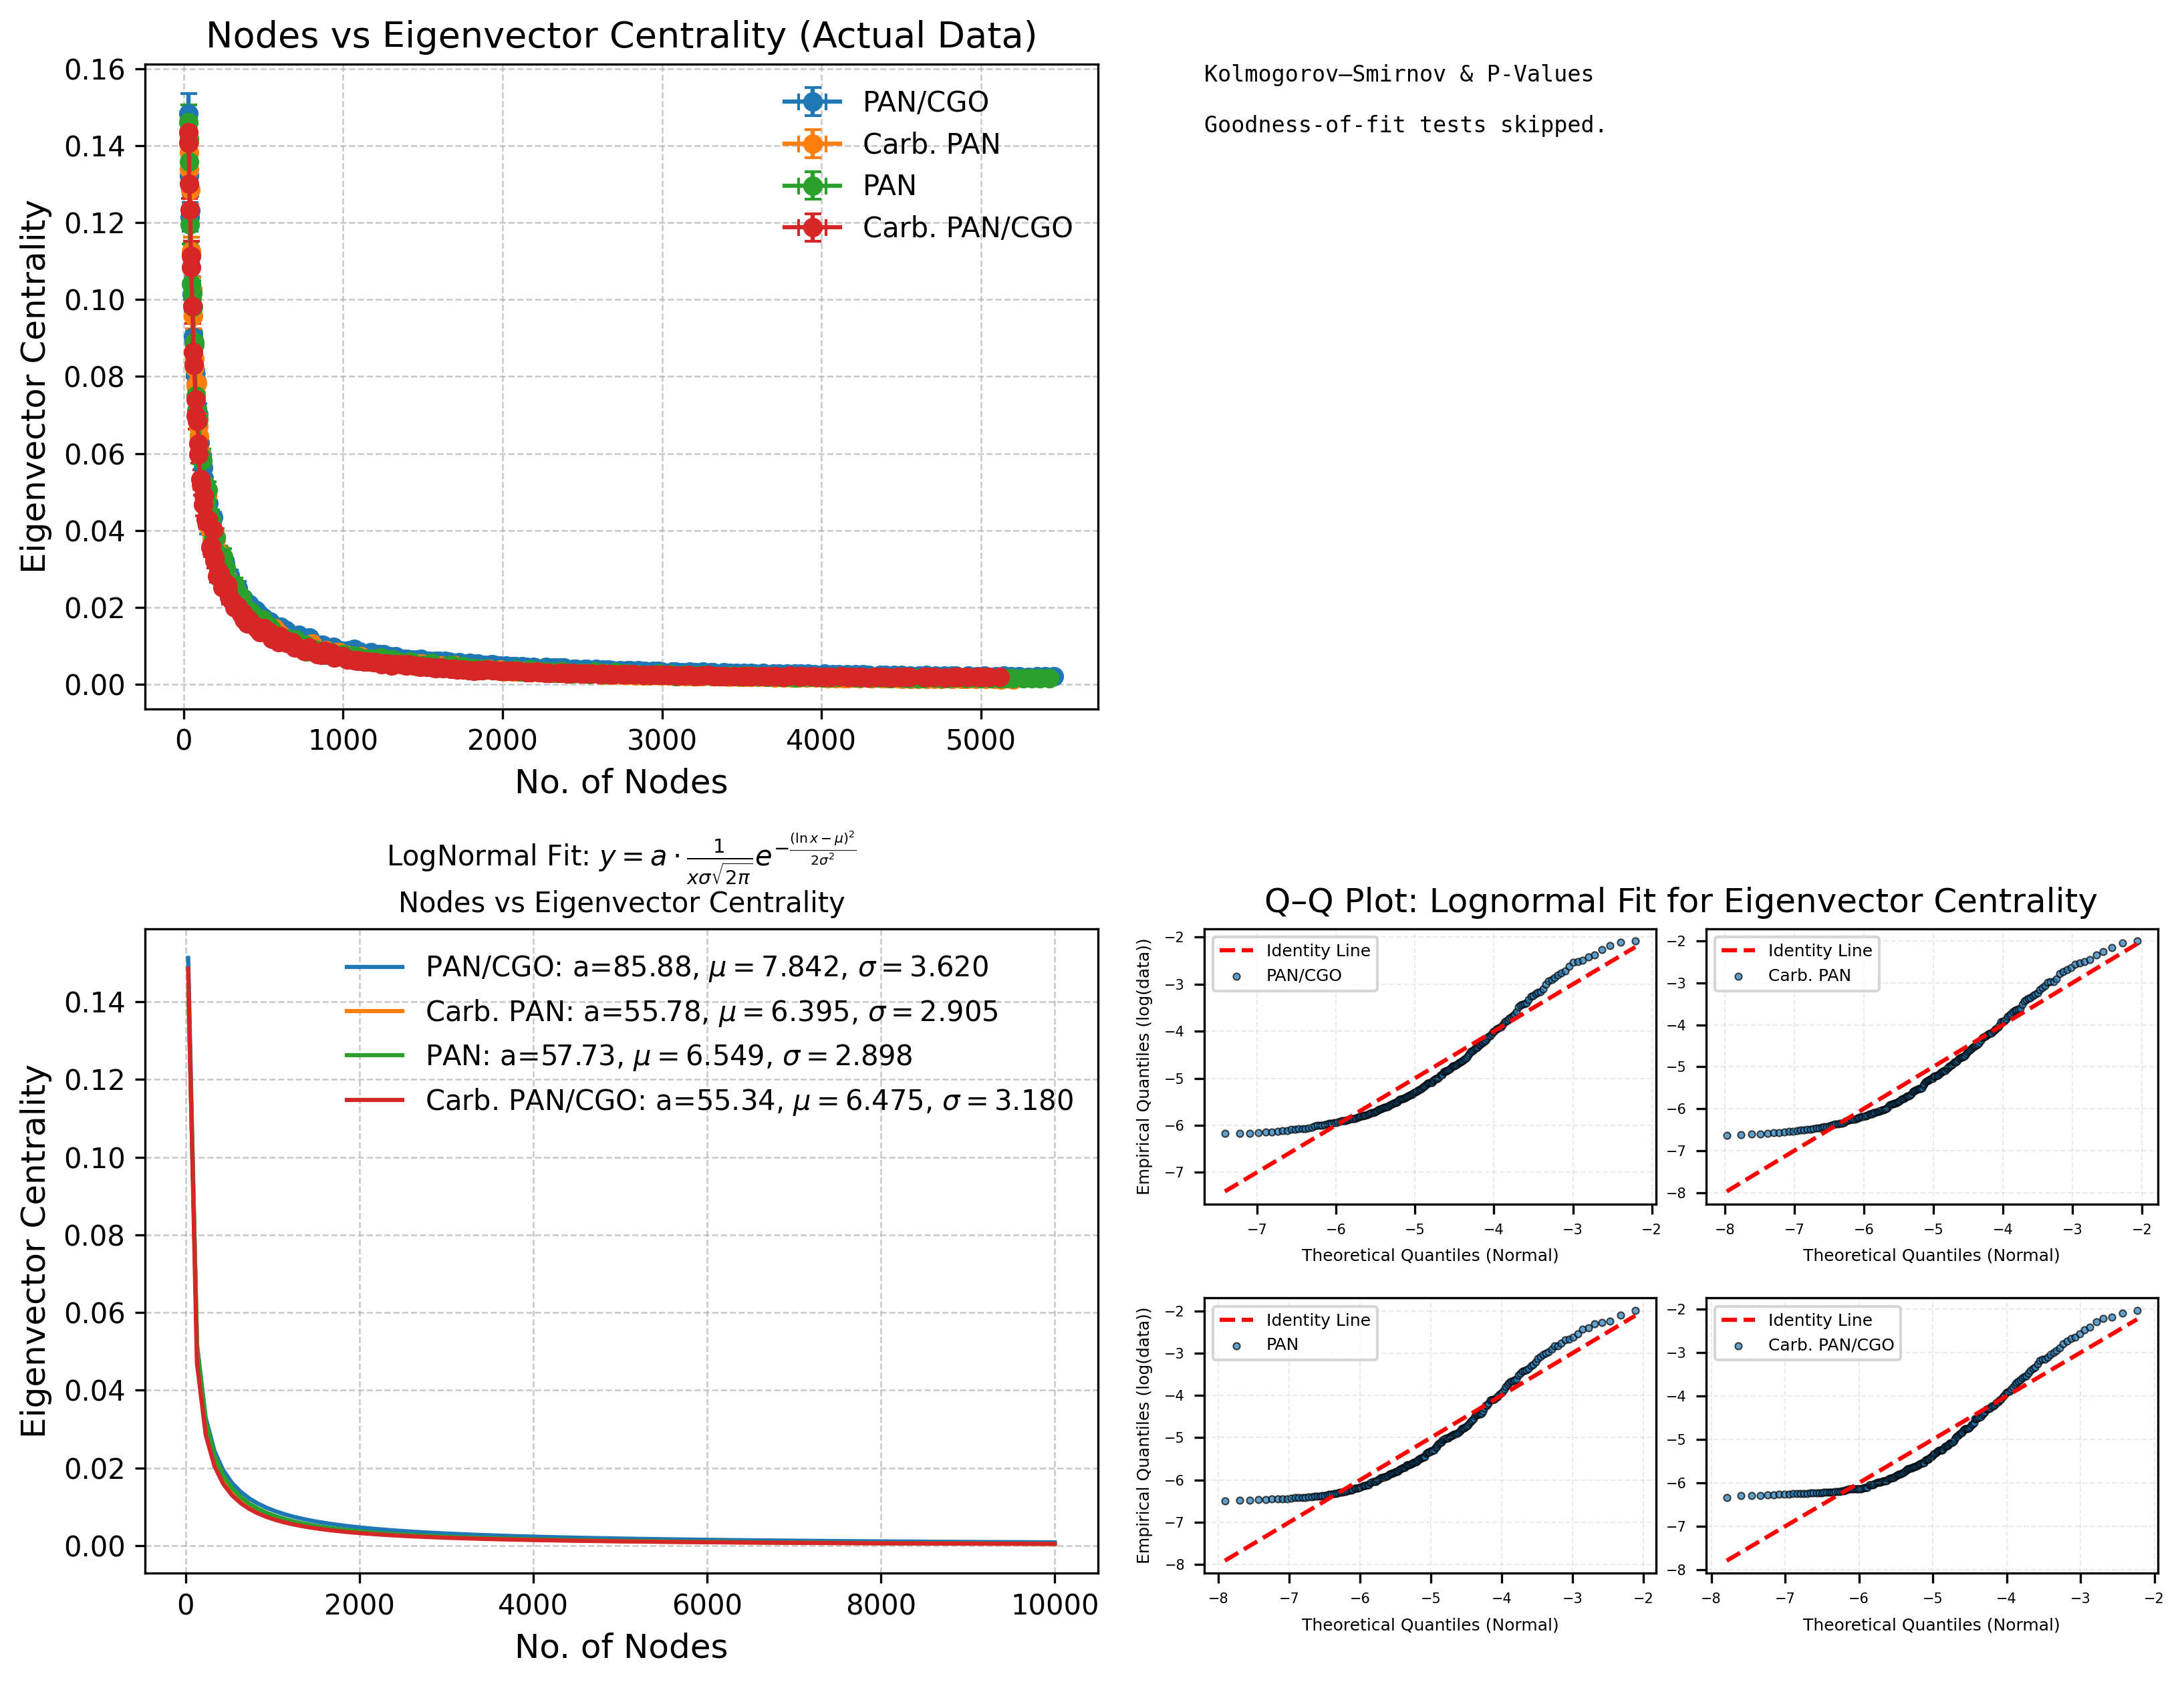

In [7]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']
plt_fig = sgt_scaling_plot("Eigenvector Centrality", df_eig, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

In [ ]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Edges", df_edges, material_labels, skip_test=True, fit_func="linear")
plt_figs.append(plt_fig)

In [ ]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
plt_fig = sgt_scaling_plot("Average Degree", df_deg, material_labels, skip_test=True)
plt_figs.append(plt_fig)

In [ ]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
plt_fig = sgt_scaling_plot("Network Diameter", df_dia, material_labels, skip_test=True)
plt_figs.append(plt_fig)

In [ ]:
"""
Assortativity Coefficient
"""
df_asc = all_sheets['Nodes-ASC']
plt_fig = sgt_scaling_plot("Assortativity Coefficient", df_asc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

In [ ]:
"""
Clustering Coefficient
"""
df_acc = all_sheets['Nodes-ACC']
plt_fig = sgt_scaling_plot("Clustering Coefficient", df_acc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

In [ ]:
"""
Global Efficiency
"""
df_ge = all_sheets['Nodes-GE']
plt_fig = sgt_scaling_plot("Global Efficiency", df_ge, material_labels, skip_test=True, fit_func="lognorm")
plt_figs.append(plt_fig)

In [ ]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)